<h1 align='center' style='color:green'>Credit Risk Modeling Project</h1>

#### Importing Libraries

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

##### Load Raw Data

In [2]:
df_customers = pd.read_csv("../DATA/raw/customers.csv")
df_loans = pd.read_csv("../DATA/raw/loans.csv")
df_bureau = pd.read_csv("../DATA/raw/bureau_data.csv")

In [3]:
#how many records do we have
df_customers.shape, df_loans.shape, df_bureau.shape

((50000, 12), (50000, 15), (50000, 8))

In [4]:
df_customers.head(3)

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,Delhi,110001
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,Tamil Nadu,600001
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,West Bengal,700001


In [5]:
df_loans.head(3)

,loan_id,cust_id,loan_purpose,loan_type,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
0,L00001,C00001,Auto,Secured,3004000,2467000,49340.0,444060,1973600,33,1630408,873386,2019-07-24,2019-08-10,False
1,L00002,C00002,Home,Secured,4161000,3883000,77660.0,698940,3106400,30,709309,464100,2019-07-24,2019-08-15,False
2,L00003,C00003,Personal,Unsecured,2401000,2170000,43400.0,390600,1736000,21,1562399,1476042,2019-07-24,2019-08-21,False


In [6]:
df_bureau.head(3)

,cust_id,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
0,C00001,1,1,42,0,0,3,7
1,C00002,3,1,96,12,60,5,4
2,C00003,2,1,82,24,147,6,58


In [7]:
# checking duplicate primary keys before merging

print("Duplicate loan_ids :", df_loans.duplicated("loan_id").sum())

print("Duplicate cust_ids :", df_customers.duplicated("cust_id").sum())
print("Duplicate cust_ids in bureau :", df_bureau.duplicated("cust_id").sum())


# both datasets are safe for merging

Duplicate loan_ids : 0
Duplicate cust_ids : 0
Duplicate cust_ids in bureau : 0


In [8]:
# taking customer's details on base loan file

df = pd.merge(df_loans, df_customers , on ="cust_id", how ='left')
df = pd.merge(df, df_bureau , on ="cust_id", how ='left')

df.head(2)

,loan_id,cust_id,loan_purpose,loan_type,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,...,city,state,zipcode,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
0,L00001,C00001,Auto,Secured,3004000,2467000,49340.0,444060,1973600,33,...,Delhi,Delhi,110001,1,1,42,0,0,3,7
1,L00002,C00002,Home,Secured,4161000,3883000,77660.0,698940,3106400,30,...,Chennai,Tamil Nadu,600001,3,1,96,12,60,5,4


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   loan_id                      50000 non-null  str    
 1   cust_id                      50000 non-null  str    
 2   loan_purpose                 50000 non-null  str    
 3   loan_type                    50000 non-null  str    
 4   sanction_amount              50000 non-null  int64  
 5   loan_amount                  50000 non-null  int64  
 6   processing_fee               50000 non-null  float64
 7   gst                          50000 non-null  int64  
 8   net_disbursement             50000 non-null  int64  
 9   loan_tenure_months           50000 non-null  int64  
 10  principal_outstanding        50000 non-null  int64  
 11  bank_balance_at_application  50000 non-null  int64  
 12  disbursal_date               50000 non-null  str    
 13  installment_start_dt       

In [10]:
# making output column int
df["default"] = df["default"].astype("int32")
df["default"].dtypes

dtype('int32')

In [12]:
df.shape

(50000, 33)

In [11]:
# checking class imbalanceness

df["default"].value_counts(normalize=True)*100 #1 : defaulter , 0 : non-defauter

default
0    91.406
1     8.594
Name: proportion, dtype: float64

### Train Test Split

In [13]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df,test_size=0.33,random_state=42,stratify=df["default"])

In [14]:
train_df["default"].value_counts(normalize=True)*100 #1 : defaulter , 0 : non-defauter

default
0    91.40597
1     8.59403
Name: proportion, dtype: float64

In [15]:
test_df["default"].value_counts(normalize=True)*100 #1 : defaulter , 0 : non-defauter

default
0    91.406061
1     8.593939
Name: proportion, dtype: float64

In [16]:
# saving splited raw data 
train_df.to_parquet("../DATA/raw/train_df_raw.parquet")
test_df.to_parquet("../DATA/raw/test_df_raw.parquet")

#### Data Cleaning

In [1]:
import pandas as pd
df_train = pd.read_parquet("../DATA/raw/train_df_raw.parquet")

In [2]:
#Handling missing values 
df_train.shape



(33500, 33)

In [3]:
#columns having null values
df_train.columns[df_train.isna().sum()>0][0]

'residence_type'

In [4]:
df_train["residence_type"].value_counts(dropna=False)

residence_type
Owned       18870
Mortgage     7914
Rented       6674
None           42
Name: count, dtype: int64

In [5]:
mode_df = df_train.groupby("city")["residence_type"].agg(lambda x: x.mode())
mode_df

city
Ahmedabad    Owned
Bangalore    Owned
Chennai      Owned
Delhi        Owned
Hyderabad    Owned
Jaipur       Owned
Kolkata      Owned
Lucknow      Owned
Mumbai       Owned
Pune         Owned
Name: residence_type, dtype: str

In [6]:
df_train["residence_type"] = df_train["residence_type"].fillna(df_train["city"].map(mode_df))


In [7]:
df_train.columns[df_train.isna().sum()>0]

Index([], dtype='str')

In [9]:
df_train.dtypes

loan_id                         object
cust_id                         object
loan_purpose                    object
loan_type                       object
sanction_amount                  int64
loan_amount                      int64
processing_fee                 float64
gst                              int64
net_disbursement                 int64
loan_tenure_months               int64
principal_outstanding            int64
bank_balance_at_application      int64
disbursal_date                  object
installment_start_dt            object
default                          int32
age                              int64
gender                          object
marital_status                  object
employment_status               object
income                           int64
number_of_dependants             int64
residence_type                  object
years_at_current_address         int64
city                            object
state                           object
zipcode                  

In [14]:
# taking categorical and numerical column

columns_continuous = df_train.select_dtypes(include=["float64","int64"]).columns
columns_categorical = df_train.select_dtypes(include=["object"]).columns

In [45]:
columns_categorical = [i for i in columns_categorical if i not in ["loan_id", "cust_id","disbursal_date","installment_start_dt"]]

In [46]:
columns_categorical

['loan_purpose',
 'loan_type',
 'gender',
 'marital_status',
 'employment_status',
 'residence_type',
 'city',
 'state']

### Box Plot Visual Outliers

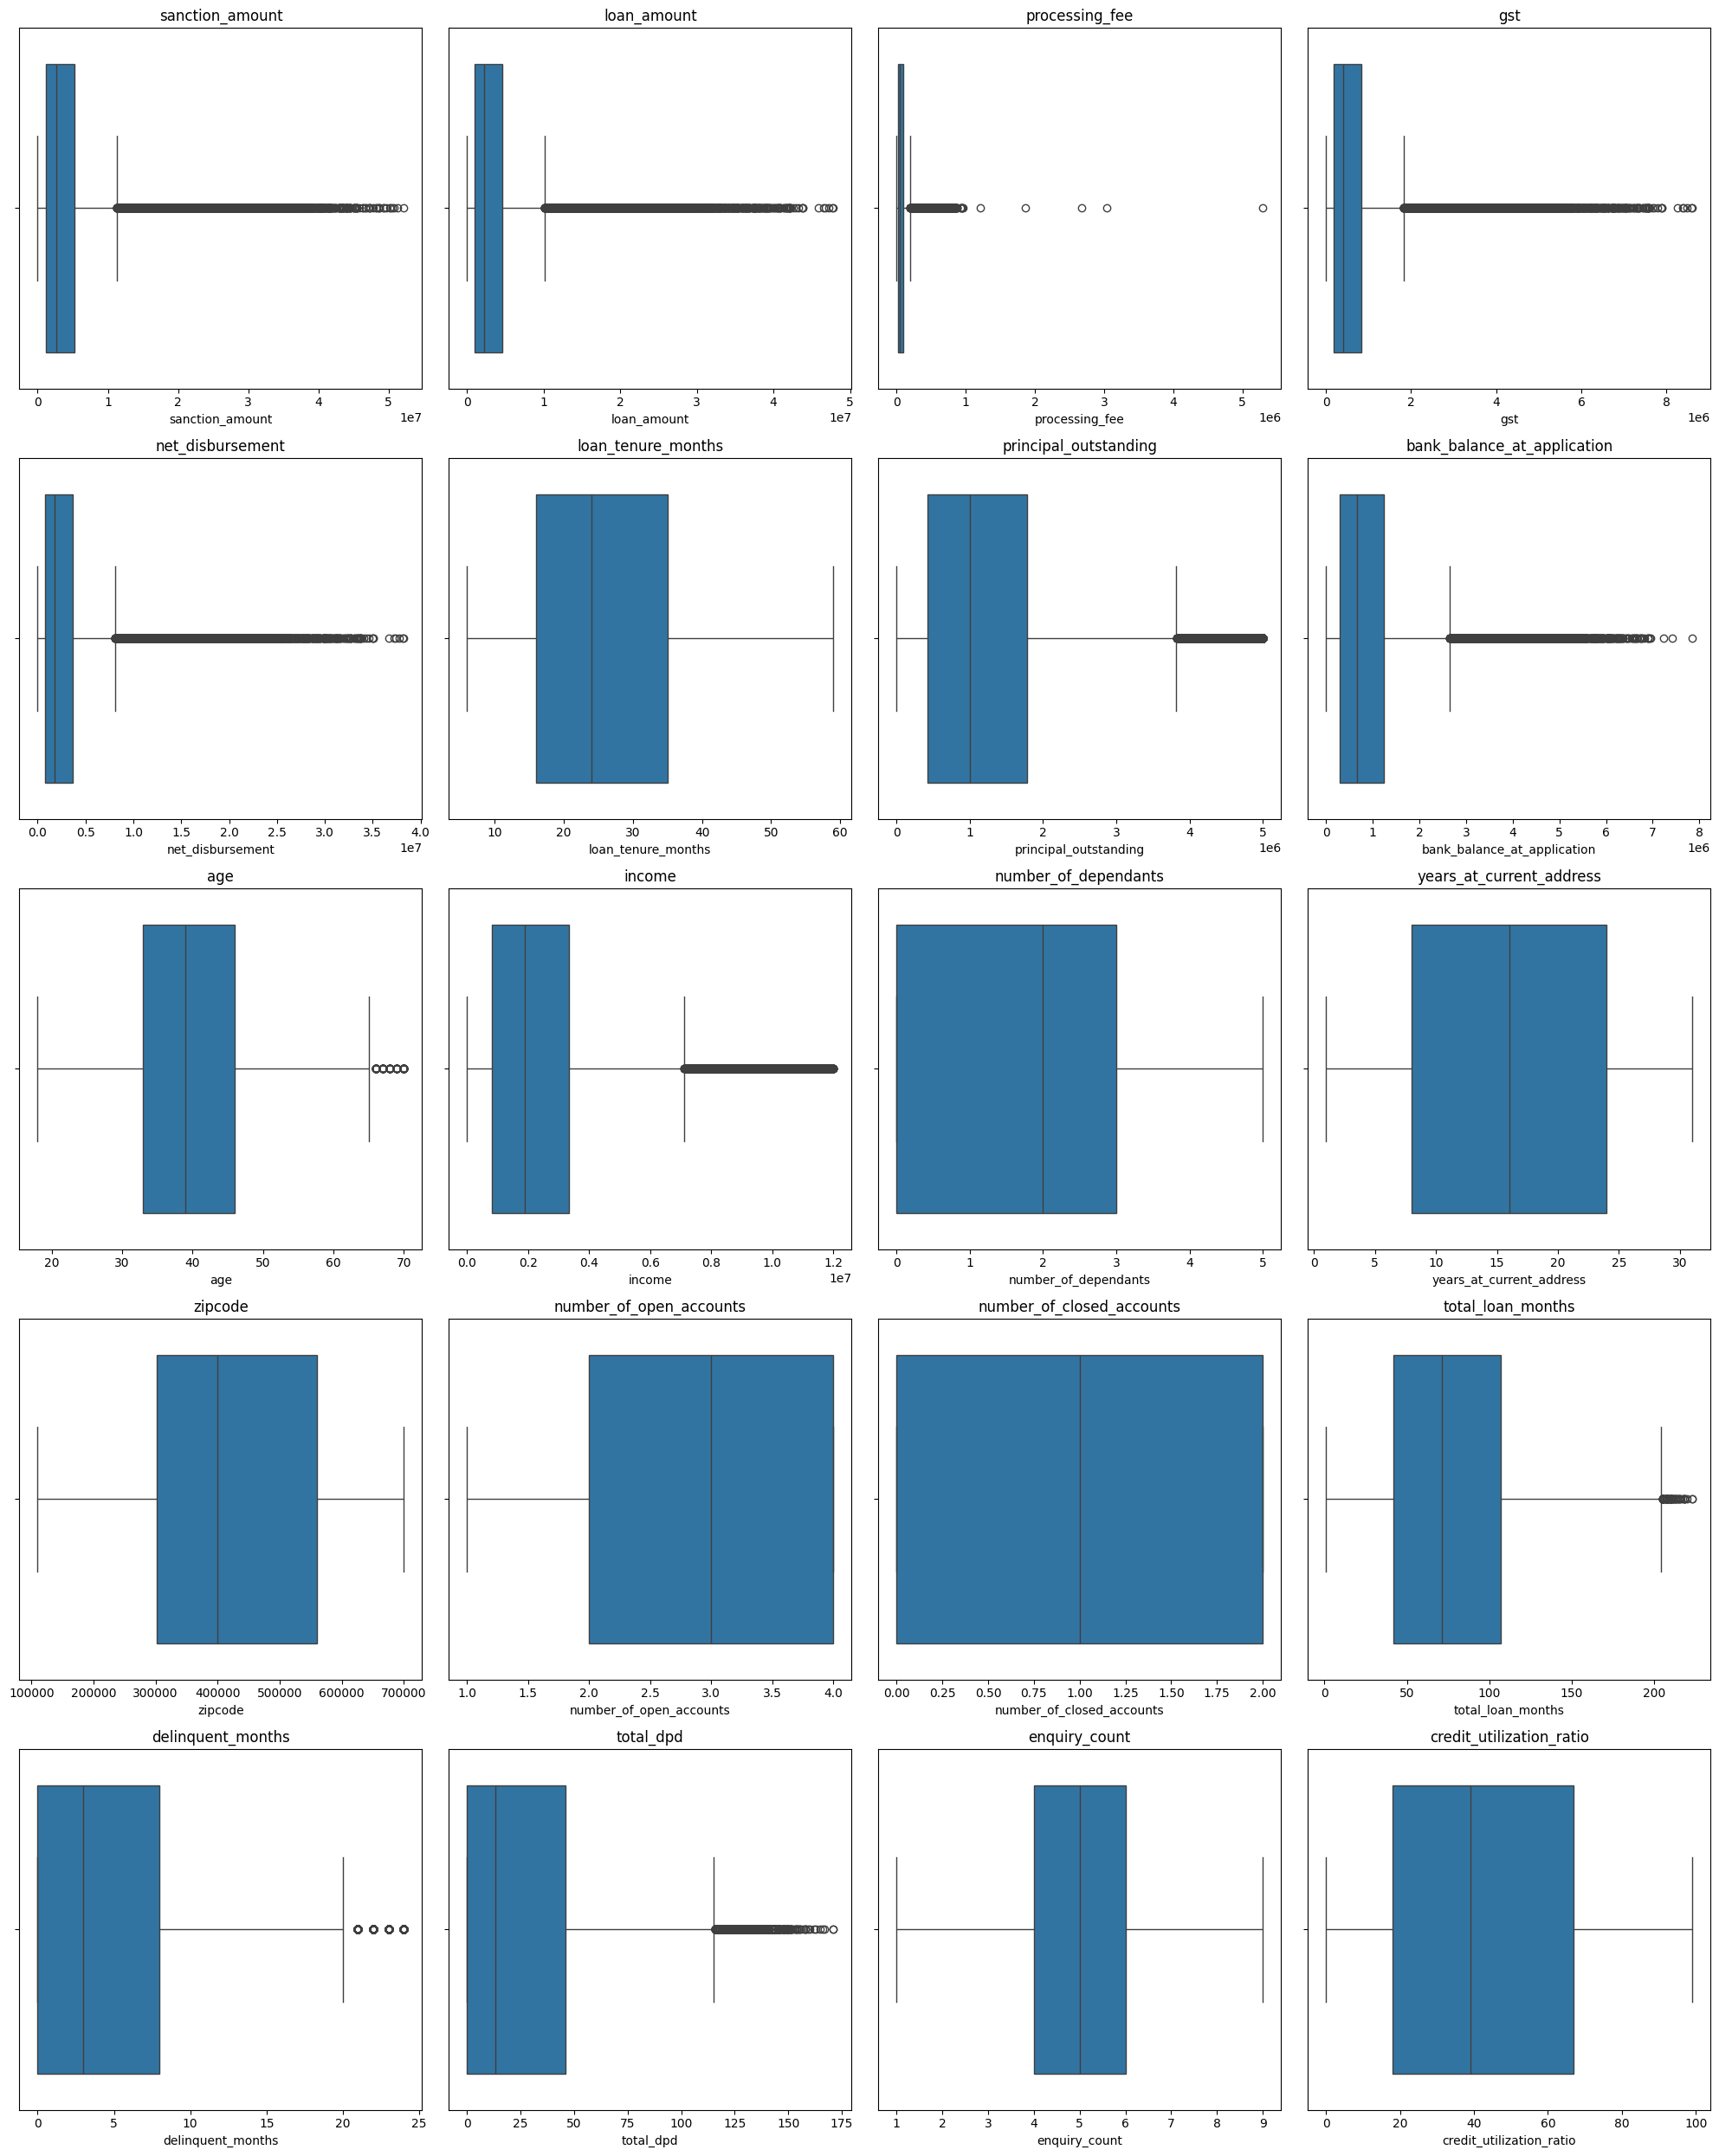

In [22]:
num_plots = len(columns_continuous)
num_cols = 4  # Number of plots per row
num_rows = (num_plots + num_cols - 1) // num_cols  # Calculate the number of rows needed

fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 5 * num_rows))  # Adjust the figure size as needed
axes = axes.flatten()  # Flatten the axes array for easier indexing

for i, col in enumerate(columns_continuous):
    sns.boxplot(x=df_train[col], ax=axes[i])
    axes[i].set_title(col)  # Set the title to the name of the variable

# If there are any empty plots (if the number of plots isn't a perfect multiple of num_cols), hide the axes
for j in range(i + 1, num_rows * num_cols):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

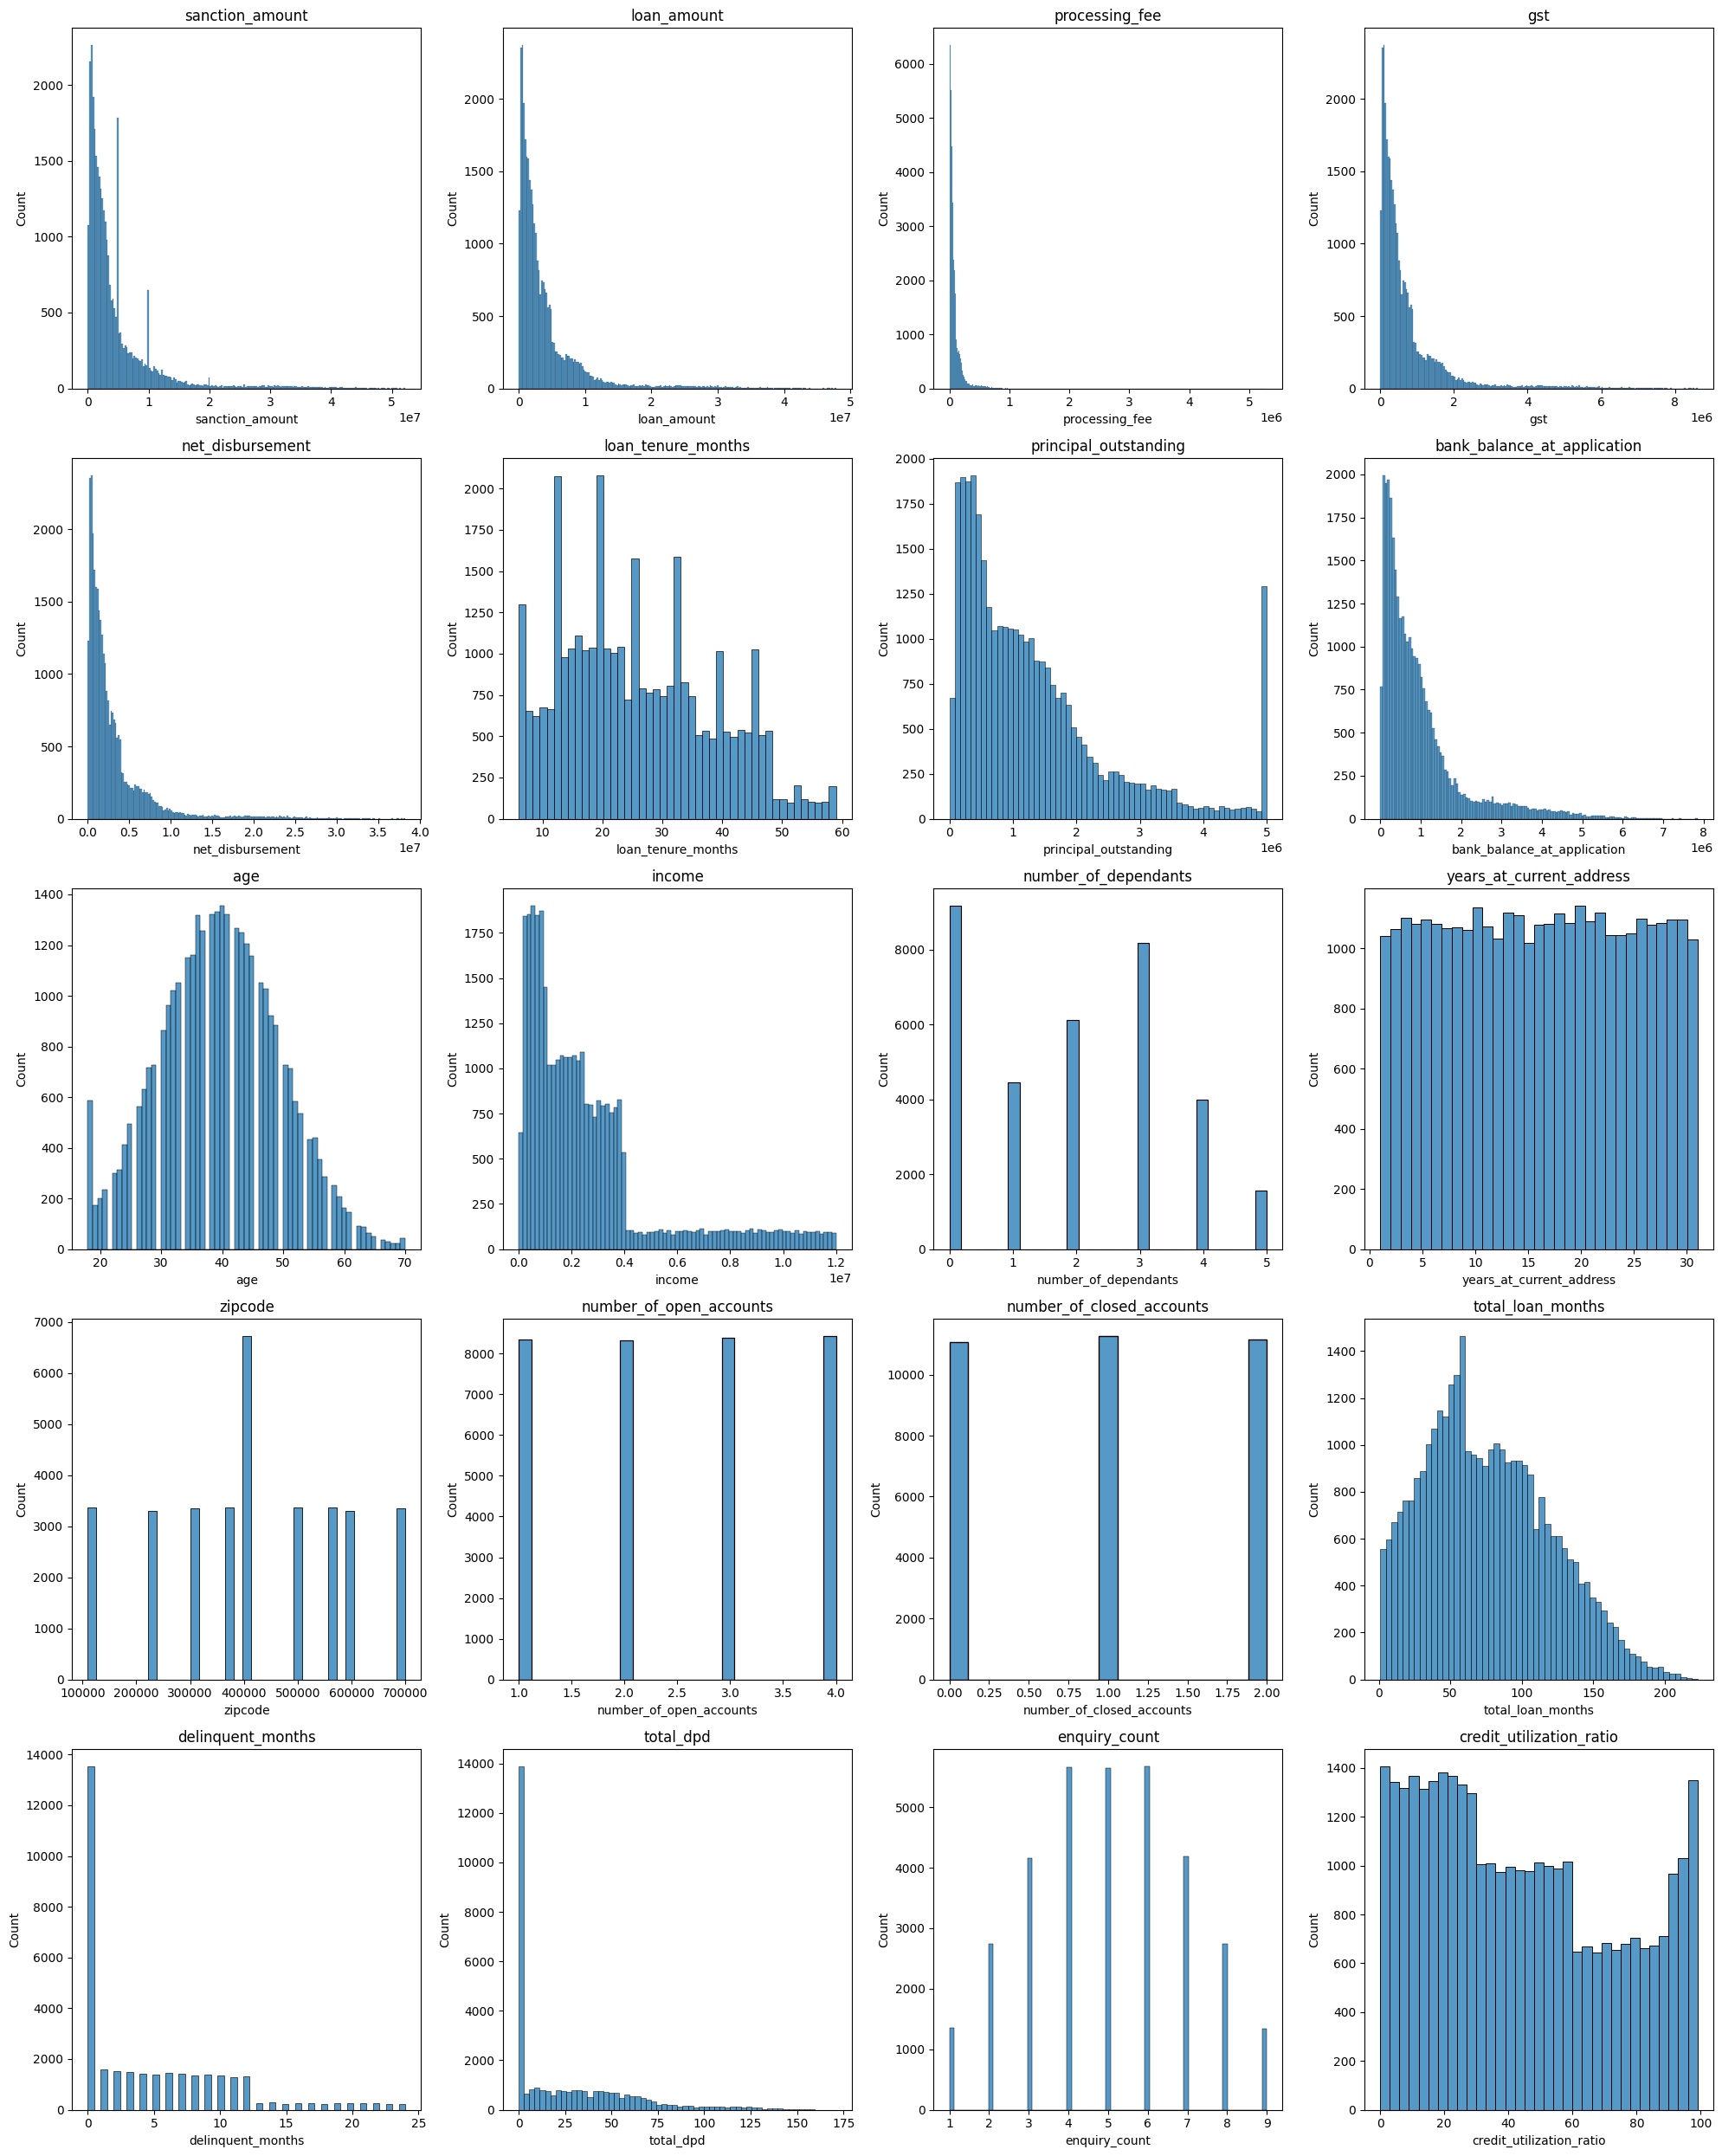

In [23]:
num_plots = len(columns_continuous)
num_cols = 4  # Number of plots per row
num_rows = (num_plots + num_cols - 1) // num_cols  # Calculate the number of rows needed

fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 5 * num_rows))  # Adjust the figure size as needed
axes = axes.flatten()  # Flatten the axes array for easier indexing

for i, col in enumerate(columns_continuous):
    sns.histplot(df_train[col], ax=axes[i])
    axes[i].set_title(col)  # Set the title to the name of the variable

# If there are any empty plots (if the number of plots isn't a perfect multiple of num_cols), hide the axes
for j in range(i + 1, num_rows * num_cols):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

### Outlier Removal: Processing Fee

In [25]:
pd.set_option('display.float_format', lambda x: '{:.2f}'.format(x))


In [26]:
df_train["processing_fee"].describe()

count     33500.00
mean      80484.06
std      113959.65
min           0.00
25%       19260.00
50%       44710.00
75%       92580.00
max     5293543.52
Name: processing_fee, dtype: float64

In [28]:
df_train.loc[df_train["processing_fee"] == df_train["processing_fee"].max(),["loan_amount","processing_fee"]]

,loan_amount,processing_fee
index,,
0,3626000,5293543.52


In [33]:
df_train.loc[df_train["processing_fee"]/df_train["loan_amount"]>0.03,["loan_amount","processing_fee"]]

,loan_amount,processing_fee
index,,
0,1738000,1858964.77
0,2234000,2669791.02
0,2616000,3036378.01
0,966000,1214492.67
0,3626000,5293543.52


In [36]:
mask = (df_train["processing_fee"] / df_train["loan_amount"]) > 0.03

df_train.loc[mask, "processing_fee"] = (0.03 * df_train.loc[mask, "loan_amount"])

In [37]:
# Use other business rules for data validation
# Rule 1: GST should not be more than 20%

df_train[(df_train.gst/df_train.loan_amount)>0.2].shape

(0, 33)

In [38]:
# Rule 2: Net disbursement should not be higher than loan_amount
df_train[df_train.net_disbursement>df_train.loan_amount].shape

(0, 33)

### Analyze Categorical Columns

In [47]:
for i in columns_categorical:
    print(i,"-->",df_train[i].unique())

loan_purpose --> ['Personal' 'Auto' 'Home' 'Education' 'Personaal']
loan_type --> ['Unsecured' 'Secured']
gender --> ['M' 'F']
marital_status --> ['Single' 'Married']
employment_status --> ['Self-Employed' 'Salaried']
residence_type --> ['Mortgage' 'Rented' 'Owned']
city --> ['Delhi' 'Jaipur' 'Chennai' 'Bangalore' 'Hyderabad' 'Ahmedabad' 'Kolkata'
 'Pune' 'Lucknow' 'Mumbai']
state --> ['Delhi' 'Rajasthan' 'Tamil Nadu' 'Karnataka' 'Telangana' 'Gujarat'
 'West Bengal' 'Maharashtra' 'Uttar Pradesh']


In [48]:
df_train['loan_purpose'] = df_train['loan_purpose'].replace('Personaal', 'Personal')
df_train['loan_purpose'].unique()

array(['Personal', 'Auto', 'Home', 'Education'], dtype=object)

In [49]:
for i in columns_categorical:
    print(i,"-->",df_train[i].unique())

loan_purpose --> ['Personal' 'Auto' 'Home' 'Education']
loan_type --> ['Unsecured' 'Secured']
gender --> ['M' 'F']
marital_status --> ['Single' 'Married']
employment_status --> ['Self-Employed' 'Salaried']
residence_type --> ['Mortgage' 'Rented' 'Owned']
city --> ['Delhi' 'Jaipur' 'Chennai' 'Bangalore' 'Hyderabad' 'Ahmedabad' 'Kolkata'
 'Pune' 'Lucknow' 'Mumbai']
state --> ['Delhi' 'Rajasthan' 'Tamil Nadu' 'Karnataka' 'Telangana' 'Gujarat'
 'West Bengal' 'Maharashtra' 'Uttar Pradesh']


## Exploring the data

In [50]:
#let us see age column

df_train.groupby("default")["age"].describe()

,count,mean,std,min,25%,50%,75%,max
default,,,,,,,,
0,30621.00,39.76,9.88,18.00,33.00,40.00,46.00,70.00
1,2879.00,37.14,9.34,18.00,31.00,37.00,44.00,70.00


**Insights**

1. Average age in the default group is little less (37.12) than the average (39.7) of the group that did not default
1. Variability (standard deviation) is mostly similar in both the groups
1. Both the groups have similar min and max ages

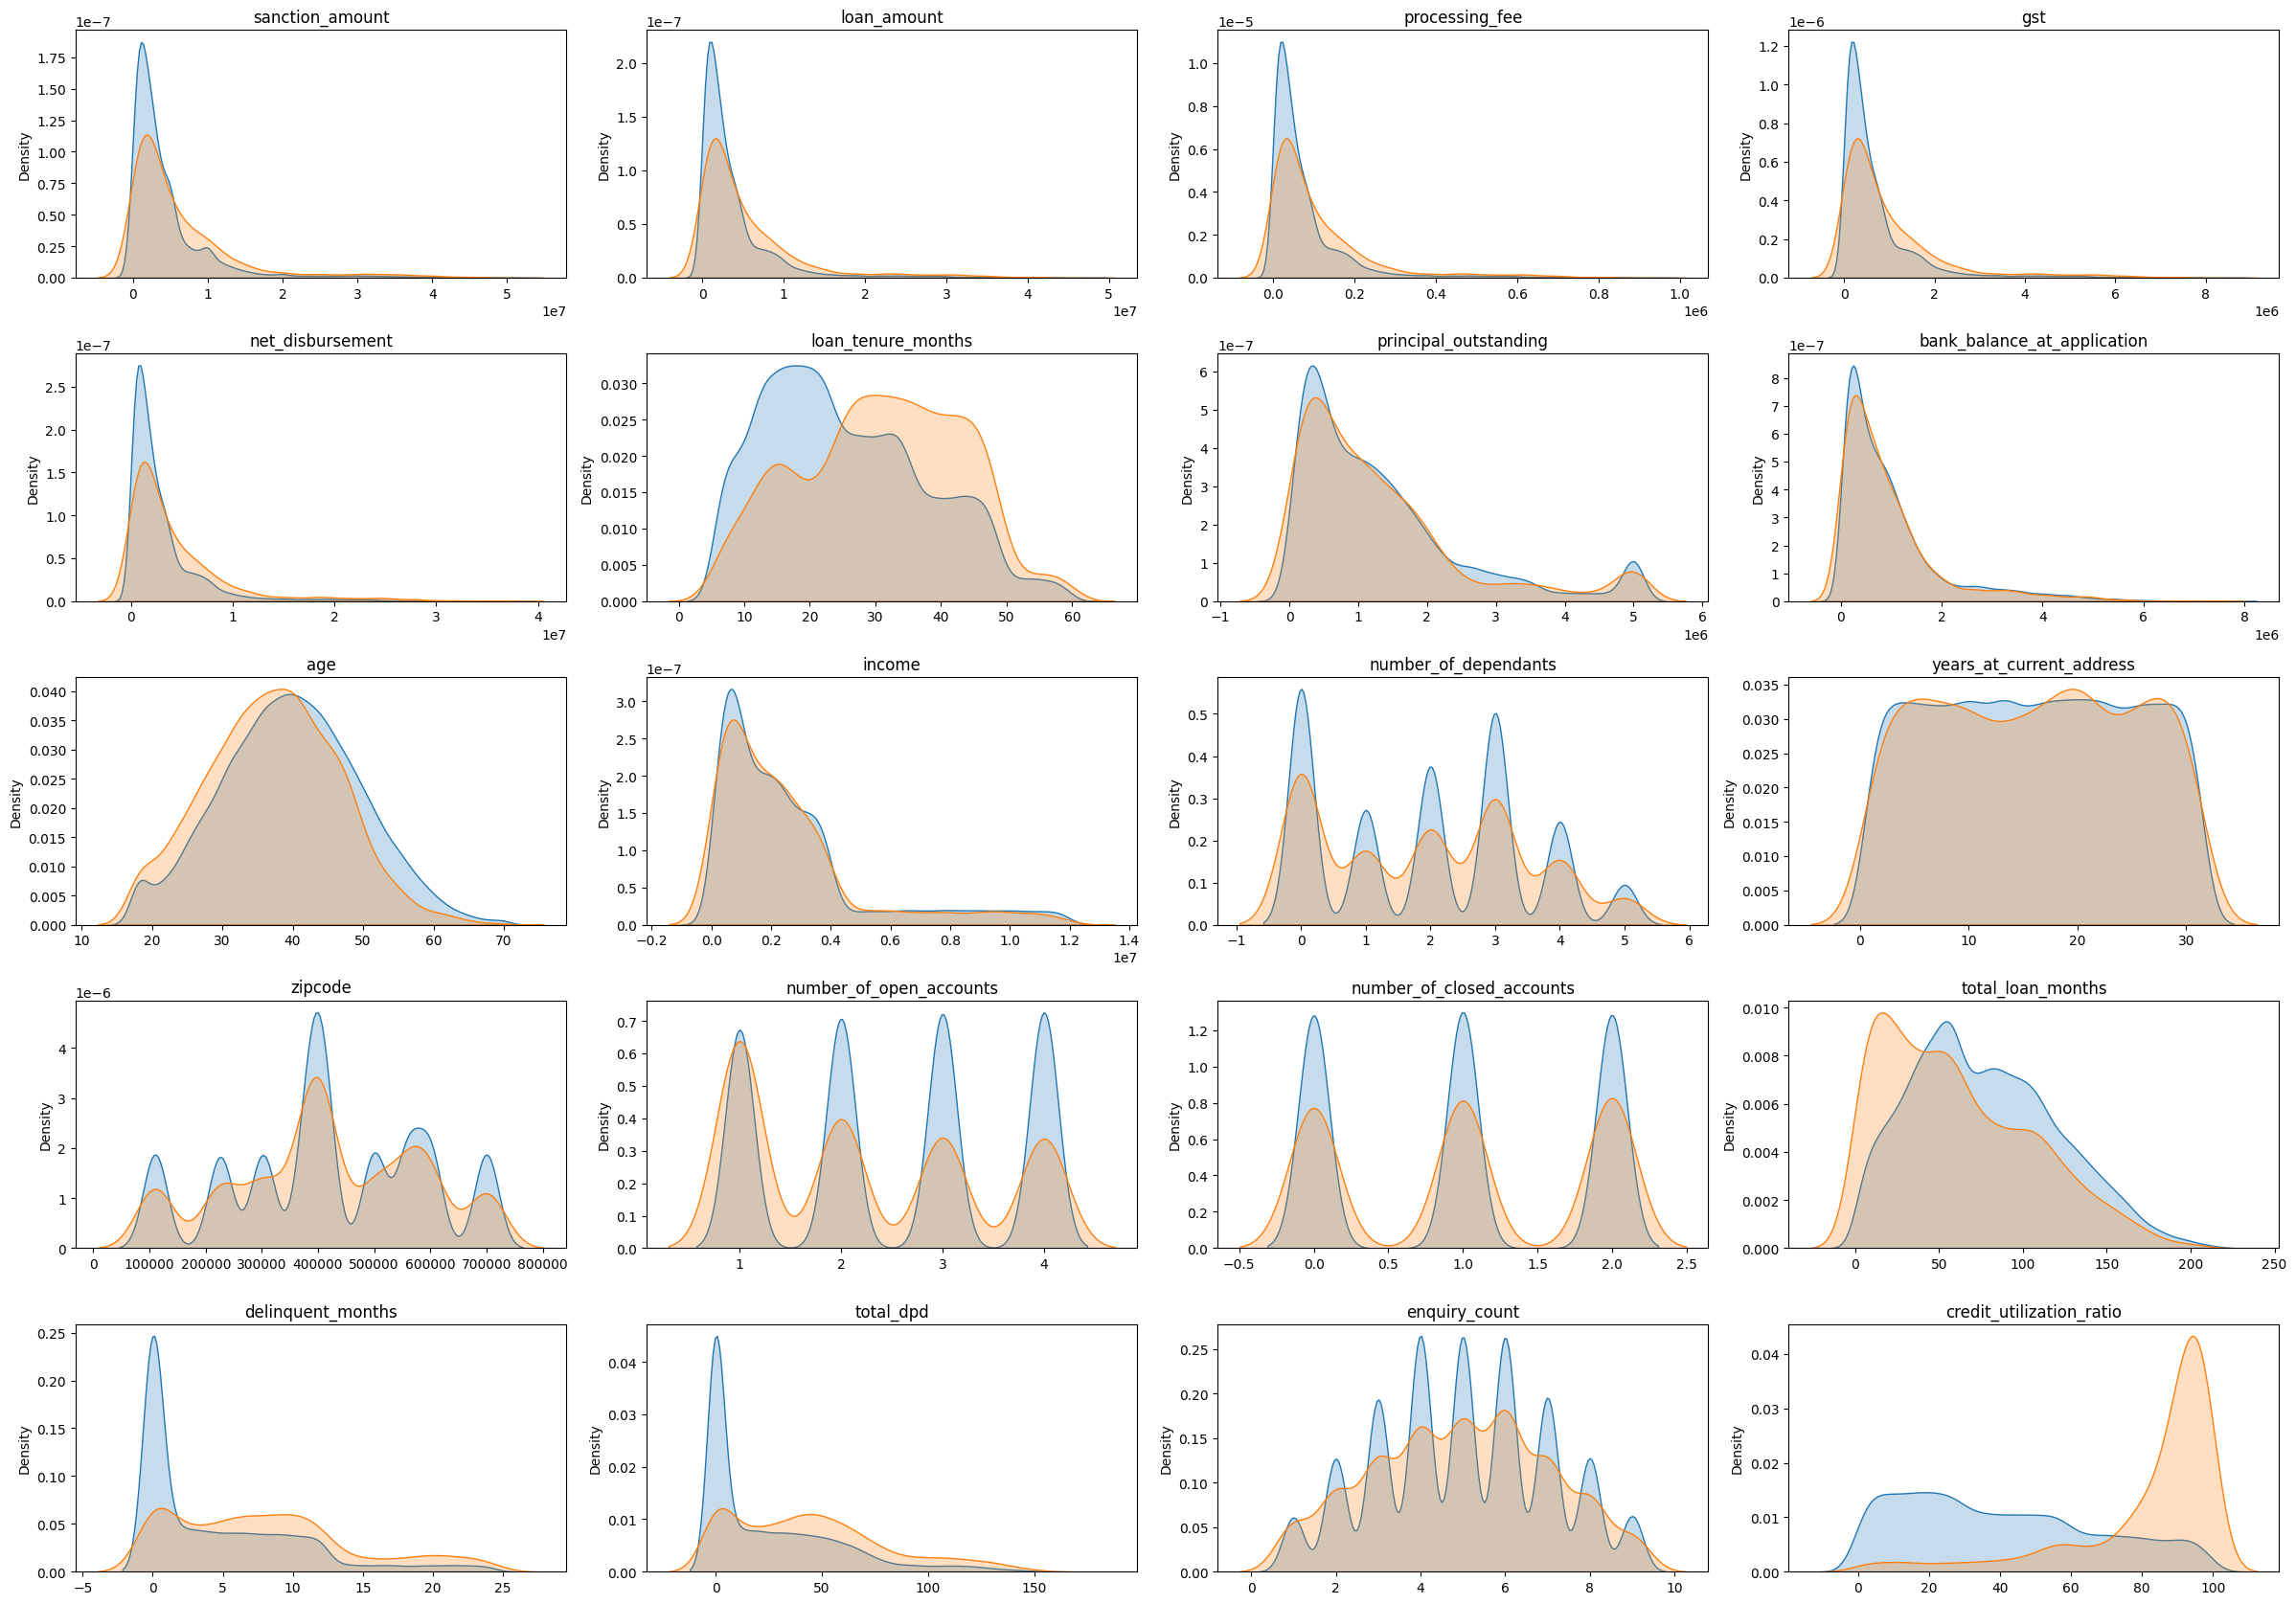

In [51]:
plt.figure(figsize=(24, 20))  # Width, height in inches

for i, col in enumerate(columns_continuous):
    plt.subplot(6, 4, i+1)  # 1 row, 4 columns, ith subplot
    sns.kdeplot(df_train[col][df_train['default']==0], fill=True, label='default=0')
    sns.kdeplot(df_train[col][df_train['default']==1], fill=True, label='default=1')
    plt.title(col)        
    plt.xlabel('')
    
plt.tight_layout()
plt.show()

**Insights**

1. In columns: loan_tenure_months, delinquent_months, total_dpd, credit_utilization, higher values indicate high likelyhood of becoming a default. Hence these 4 looks like strong predictors
1. In remaining columns the distributions do not give any obvious insights
1. Why loan_amount and income did not give any signs of being strong predictors? May be when we combine these two and get loan to income ratio (LTI), that may have influence on the target variable. We will explore more later

<h2 align='center' style='color:green'>Feature Engineering</h2>

In [52]:
#features to create
# 1) Loan to income(LTI)
# 2) delinquency Ratio
# 3) Avg DPD per delinquency


#### LOAN_TO_INCOME

In [54]:
df_train[["loan_amount", "income"]].tail(3)

,loan_amount,income
index,,
0,1420000,2470000
0,2753000,2472000
0,1890000,1274000


In [82]:
df_train.loc[df_train["loan_to_income"].isna(),["loan_amount","income"]]

,loan_amount,income
index,,
0,0,0
0,0,0
0,0,0
0,0,0
0,0,0
0,0,0


In [55]:
df_train['loan_to_income'] = round(df_train['loan_amount'] / df_train['income'],2)
df_train['loan_to_income'].describe()

count   33494.00
mean        1.56
std         0.97
min         0.30
25%         0.77
50%         1.16
75%         2.46
max         4.57
Name: loan_to_income, dtype: float64

In [83]:
df_train["loan_to_income"] = df_train["loan_to_income"].fillna(0)

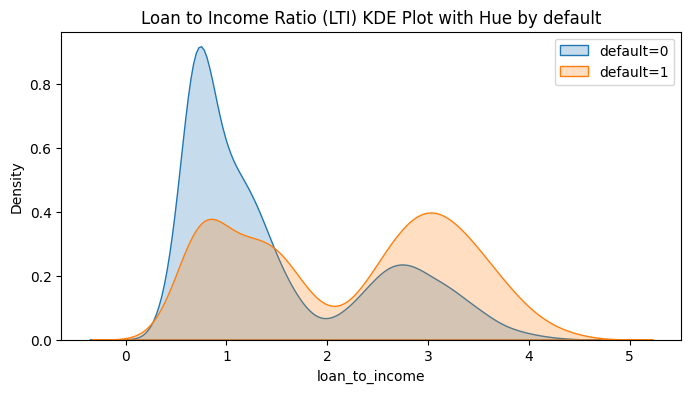

In [84]:
# does this feature having any explainability power?
plt.figure(figsize=(8, 4))
sns.kdeplot(df_train['loan_to_income'][df_train['default'] == 0], fill=True, label='default=0')
sns.kdeplot(df_train['loan_to_income'][df_train['default'] == 1], fill=True, label='default=1')
plt.title(f"Loan to Income Ratio (LTI) KDE Plot with Hue by default")
plt.legend()
plt.show()

**Insights**
1. Blue graph has majority of its values on lower side of LTI
2. Orange graph has many values when LTI is higher indicating that higher LTI means high risk loan

#### delinquency Ratio

In [57]:
df_train['delinquency_ratio'] = (df_train['delinquent_months']*100 / df_train['total_loan_months']).round(1)


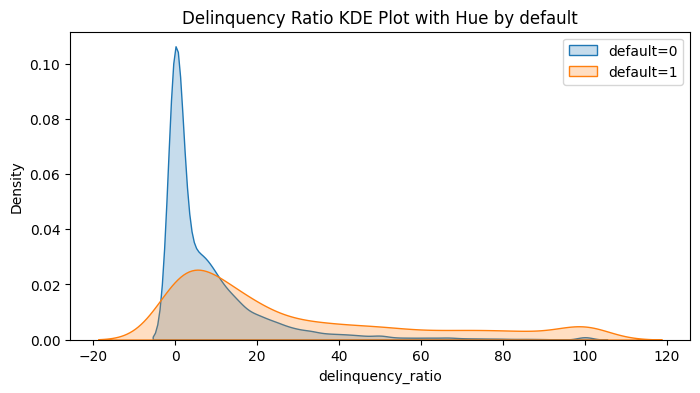

In [58]:
plt.figure(figsize=(8, 4))
sns.kdeplot(df_train['delinquency_ratio'][df_train['default'] == 0], fill=True, label='default=0')
sns.kdeplot(df_train['delinquency_ratio'][df_train['default'] == 1], fill=True, label='default=1')
plt.title(f"Delinquency Ratio KDE Plot with Hue by default")
plt.legend()
plt.show()

**Insights**
1. Blue graph has majority of its values on lower side of LTI
2. Orange graph has many values when delinquency ratio is higher indicating some correlation on default

#### Generate Avg DPD Per Delinquency

In [59]:
df_train['avg_dpd_per_delinquency'] = np.where(
    df_train['delinquent_months'] != 0,
    (df_train['total_dpd'] / df_train['delinquent_months']).round(1),
    0
)


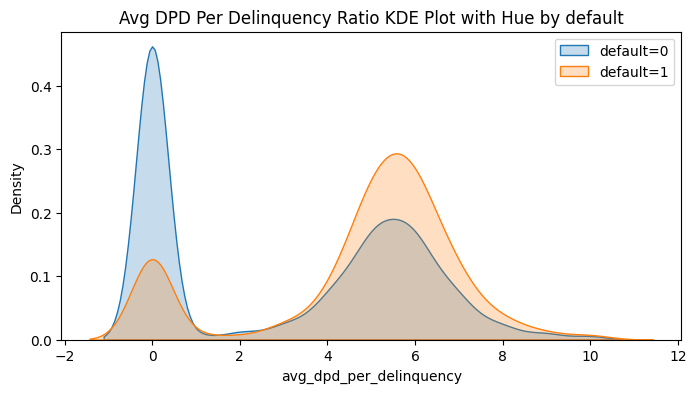

In [60]:
plt.figure(figsize=(8, 4))
sns.kdeplot(df_train['avg_dpd_per_delinquency'][df_train['default'] == 0], fill=True, label='default=0')
sns.kdeplot(df_train['avg_dpd_per_delinquency'][df_train['default'] == 1], fill=True, label='default=1')
plt.title(f"Avg DPD Per Delinquency Ratio KDE Plot with Hue by default")
plt.legend()
plt.show()

**Insights**

1. Graph clearly shows more occurances of default cases when avg_dpd_per_delinquency is high. This means this column is a strong predictor

#### columns to remove : by business understanding

In [64]:
drop_cols = ['disbursal_date', 'installment_start_dt', 'loan_amount', 'income', 
                              'total_loan_months', 'delinquent_months', 'total_dpd']

id_cols = ["loan_id","cust_id"]

In [91]:
df_train_1 = df_train.drop(drop_cols,axis=1)
df_train_1 = df_train_1.drop(id_cols,axis=1)

In [92]:
df_train_1.columns

Index(['loan_purpose', 'loan_type', 'sanction_amount', 'processing_fee', 'gst',
       'net_disbursement', 'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'default', 'age', 'gender',
       'marital_status', 'employment_status', 'number_of_dependants',
       'residence_type', 'years_at_current_address', 'city', 'state',
       'zipcode', 'number_of_open_accounts', 'number_of_closed_accounts',
       'enquiry_count', 'credit_utilization_ratio', 'loan_to_income',
       'delinquency_ratio', 'avg_dpd_per_delinquency'],
      dtype='str')

### VIF TO MEASURE MULTICOLINEARITY

In [93]:
from sklearn.preprocessing import MinMaxScaler

In [94]:
X_train = df_train_1.drop("default",axis=1)
y_train = df_train_1["default"]

scaler = MinMaxScaler()
cols_to_scale = X_train.select_dtypes(include=["int64","float64"]).columns
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

In [95]:
X_train.describe()

,sanction_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,age,number_of_dependants,years_at_current_address,zipcode,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,loan_to_income,delinquency_ratio,avg_dpd_per_delinquency
count,33500.00,33500.00,33500.00,33500.00,33500.00,33500.00,33500.00,33500.00,33500.00,33500.00,33500.00,33500.00,33500.00,33500.00,33500.00,33500.00,33500.00,33500.00
mean,0.09,0.08,0.08,0.08,0.38,0.27,0.13,0.41,0.39,0.50,0.52,0.50,0.50,0.50,0.44,0.34,0.10,0.33
std,0.12,0.11,0.11,0.11,0.23,0.24,0.13,0.19,0.31,0.30,0.29,0.37,0.41,0.25,0.30,0.21,0.17,0.29
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.02,0.02,0.02,0.02,0.19,0.08,0.04,0.29,0.00,0.23,0.33,0.33,0.00,0.38,0.18,0.17,0.00,0.00
50%,0.05,0.05,0.05,0.05,0.34,0.20,0.08,0.40,0.40,0.50,0.49,0.67,0.50,0.50,0.39,0.25,0.04,0.43
75%,0.10,0.10,0.10,0.10,0.55,0.36,0.16,0.54,0.60,0.77,0.76,1.00,1.00,0.62,0.68,0.54,0.13,0.57
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


In [96]:
X_train.isna().sum()

loan_purpose                   0
loan_type                      0
sanction_amount                0
processing_fee                 0
gst                            0
net_disbursement               0
loan_tenure_months             0
principal_outstanding          0
bank_balance_at_application    0
age                            0
gender                         0
marital_status                 0
employment_status              0
number_of_dependants           0
residence_type                 0
years_at_current_address       0
city                           0
state                          0
zipcode                        0
number_of_open_accounts        0
number_of_closed_accounts      0
enquiry_count                  0
credit_utilization_ratio       0
loan_to_income                 0
delinquency_ratio              0
avg_dpd_per_delinquency        0
dtype: int64

In [97]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df['Column'] = data.columns
    vif_df['VIF'] = [variance_inflation_factor(data.values,i) for i in range(data.shape[1])]
    return vif_df

In [101]:
vif_df = calculate_vif(X_train[cols_to_scale])

c:\Users\naban\OneDrive\Desktop\PROJECT_CREDIT_RISK\creditproj\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [102]:
vif_df

,Column,VIF
0,sanction_amount,102.34
1,processing_fee,208412.89
2,gst,inf
3,net_disbursement,inf
4,loan_tenure_months,6.25
5,principal_outstanding,16.66
6,bank_balance_at_application,9.47
7,age,5.70
8,number_of_dependants,2.73
9,years_at_current_address,3.45


In [99]:
features_to_drop_vif = ['sanction_amount', 'processing_fee', 'gst', 'net_disbursement','principal_outstanding']


X_train_1 = X_train.drop(features_to_drop_vif, axis='columns')
numeric_columns = X_train_1.select_dtypes(['int64', 'float64']).columns
numeric_columns

Index(['loan_tenure_months', 'bank_balance_at_application', 'age',
       'number_of_dependants', 'years_at_current_address', 'zipcode',
       'number_of_open_accounts', 'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'loan_to_income', 'delinquency_ratio',
       'avg_dpd_per_delinquency'],
      dtype='str')

In [100]:
calculate_vif(X_train_1[numeric_columns])

,Column,VIF
0,loan_tenure_months,6.10
1,bank_balance_at_application,1.84
2,age,5.38
3,number_of_dependants,2.72
4,years_at_current_address,3.43
5,zipcode,3.79
6,number_of_open_accounts,4.35
7,number_of_closed_accounts,2.38
8,enquiry_count,6.39
9,credit_utilization_ratio,2.93


In [104]:
numeric_columns

Index(['loan_tenure_months', 'bank_balance_at_application', 'age',
       'number_of_dependants', 'years_at_current_address', 'zipcode',
       'number_of_open_accounts', 'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'loan_to_income', 'delinquency_ratio',
       'avg_dpd_per_delinquency'],
      dtype='str')

# Feature selection : Categorical Features

### Calculate WOE and IV

In [106]:
def calculate_woe_iv(df, feature, target):
    grouped = df.groupby(feature)[target].agg(['count','sum'])
    grouped = grouped.rename(columns={'count': 'total', 'sum': 'good'})
    grouped['bad']=grouped['total']-grouped['good']
    
    total_good = grouped['good'].sum()
    total_bad = grouped['bad'].sum()
    
    grouped['good_pct'] = grouped['good'] / total_good
    grouped['bad_pct'] = grouped['bad'] / total_bad
    grouped['woe'] = np.log(grouped['good_pct']/ grouped['bad_pct'])
    grouped['iv'] = (grouped['good_pct'] -grouped['bad_pct'])*grouped['woe']
    
    grouped['woe'] = grouped['woe'].replace([np.inf, -np.inf], 0)
    grouped['iv'] = grouped['iv'].replace([np.inf, -np.inf], 0)
    
    total_iv = grouped['iv'].sum()
    
    return grouped, total_iv

grouped, total_iv = calculate_woe_iv(pd.concat([X_train_1, y_train],axis=1), 'loan_purpose', 'default')
grouped

,total,good,bad,good_pct,bad_pct,woe,iv
loan_purpose,,,,,,,
Auto,6637,290,6347,0.10,0.21,-0.72,0.08
Education,5012,502,4510,0.17,0.15,0.17,0.00
Home,10114,1543,8571,0.54,0.28,0.65,0.17
Personal,11737,544,11193,0.19,0.37,-0.66,0.12


In [107]:
iv_values = {}

for feature in X_train_1.columns:
    if X_train_1[feature].dtype == 'object':
        _, iv = calculate_woe_iv(pd.concat([X_train_1, y_train],axis=1), feature, 'default' )
    else:
        X_binned = pd.cut(X_train_1[feature], bins=10, labels=False)
        _, iv = calculate_woe_iv(pd.concat([X_binned, y_train],axis=1), feature, 'default' )
    iv_values[feature] = iv
        
iv_values

{'loan_purpose': np.float64(0.3642954450868793),
 'loan_type': np.float64(0.15987303265643546),
 'loan_tenure_months': np.float64(0.21493558900252938),
 'bank_balance_at_application': np.float64(0.006285189200284934),
 'age': np.float64(0.08677460154707643),
 'gender': np.float64(0.0002738953479165612),
 'marital_status': np.float64(0.0007728945973381361),
 'employment_status': np.float64(0.003991927096249557),
 'number_of_dependants': np.float64(0.001395092638002727),
 'residence_type': np.float64(0.24265575433200612),
 'years_at_current_address': np.float64(0.002650402570730145),
 'city': np.float64(0.0016580454057813943),
 'state': np.float64(0.0015708877660569978),
 'zipcode': np.float64(0.0013606686369193287),
 'number_of_open_accounts': np.float64(0.09158606277120863),
 'number_of_closed_accounts': np.float64(0.0007428897514053728),
 'enquiry_count': np.float64(0.007180029808204474),
 'credit_utilization_ratio': np.float64(2.361655713305037),
 'loan_to_income': np.float64(0.46776

In [108]:
pd.set_option('display.float_format', lambda x: '{:.3f}'.format(x))

iv_df = pd.DataFrame(list(iv_values.items()), columns=['Feature', 'IV'])
iv_df = iv_df.sort_values(by='IV', ascending=False)
iv_df

,Feature,IV
17,credit_utilization_ratio,2.362
19,delinquency_ratio,0.724
18,loan_to_income,0.468
20,avg_dpd_per_delinquency,0.412
0,loan_purpose,0.364
9,residence_type,0.243
2,loan_tenure_months,0.215
1,loan_type,0.160
14,number_of_open_accounts,0.092
4,age,0.087


In [109]:
# select features that has IV > 0.02
selected_features_iv = [feature for feature, iv in iv_values.items() if iv > 0.02]
selected_features_iv

['loan_purpose',
 'loan_type',
 'loan_tenure_months',
 'age',
 'residence_type',
 'number_of_open_accounts',
 'credit_utilization_ratio',
 'loan_to_income',
 'delinquency_ratio',
 'avg_dpd_per_delinquency']

In [111]:
import pickle

pickle.dump(
    selected_features_iv,
    open("../pickle_files/model_features.pkl", "wb")
)